In [1]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score, get_insulation_fixed
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q


NPROC = 8
resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution)

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 2
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from ggner_3d import plotting
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

In [2]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/control_insulation_10kb_500000_window.csv'),
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_insulation_10kb_500000_window.csv'),
]

comparisons = [(0,1)]
comparisons_str = ['Control_Pol2Degron']
sample_names_str = ['Control', 'Pol2Degron']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_['WTnoUV'].bins()[:], bin_column='idx1') for df in dfs
]

tads = make_tads(dfs[0][['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN).sort_values(['chrom', 'start', 'end']).reset_index(drop=True)

Control_Pol2Degron: Preserved / Increase ::: 1653
Control_Pol2Degron: Preserved / Decrease ::: 737


In [3]:
flank_ratio = 0.25
tads['flank_size'] = (tads['end'] - tads['start']) * flank_ratio
tads['flank_start'] = tads['start'] - tads['flank_size']
tads['flank_end'] = tads['end'] + tads['flank_size']

In [4]:
# ctcf

ctcf_dict = {
    'control': ["/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245909_DLD1asyn_Ctrl_CTCF_rep1.bw",
                "/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245910_DLD1asyn_Ctrl_CTCF_rep2.bw"],
    'degron': ["/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245911_DLD1asyn_Aux_CTCF_rep1.bw",
               "/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245912_DLD1asyn_Aux_CTCF_rep2.bw"]
}

In [5]:
import importlib
from ggner_3d import bbi_helpers
importlib.reload(bbi_helpers)
from ggner_3d.bbi_helpers import stackup_bw_dict_q

nbins = 150

In [6]:
# q stackups - TADS

ctcf_stackup = stackup_bw_dict(ctcf_dict, tads, nbins=nbins)

/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:19: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


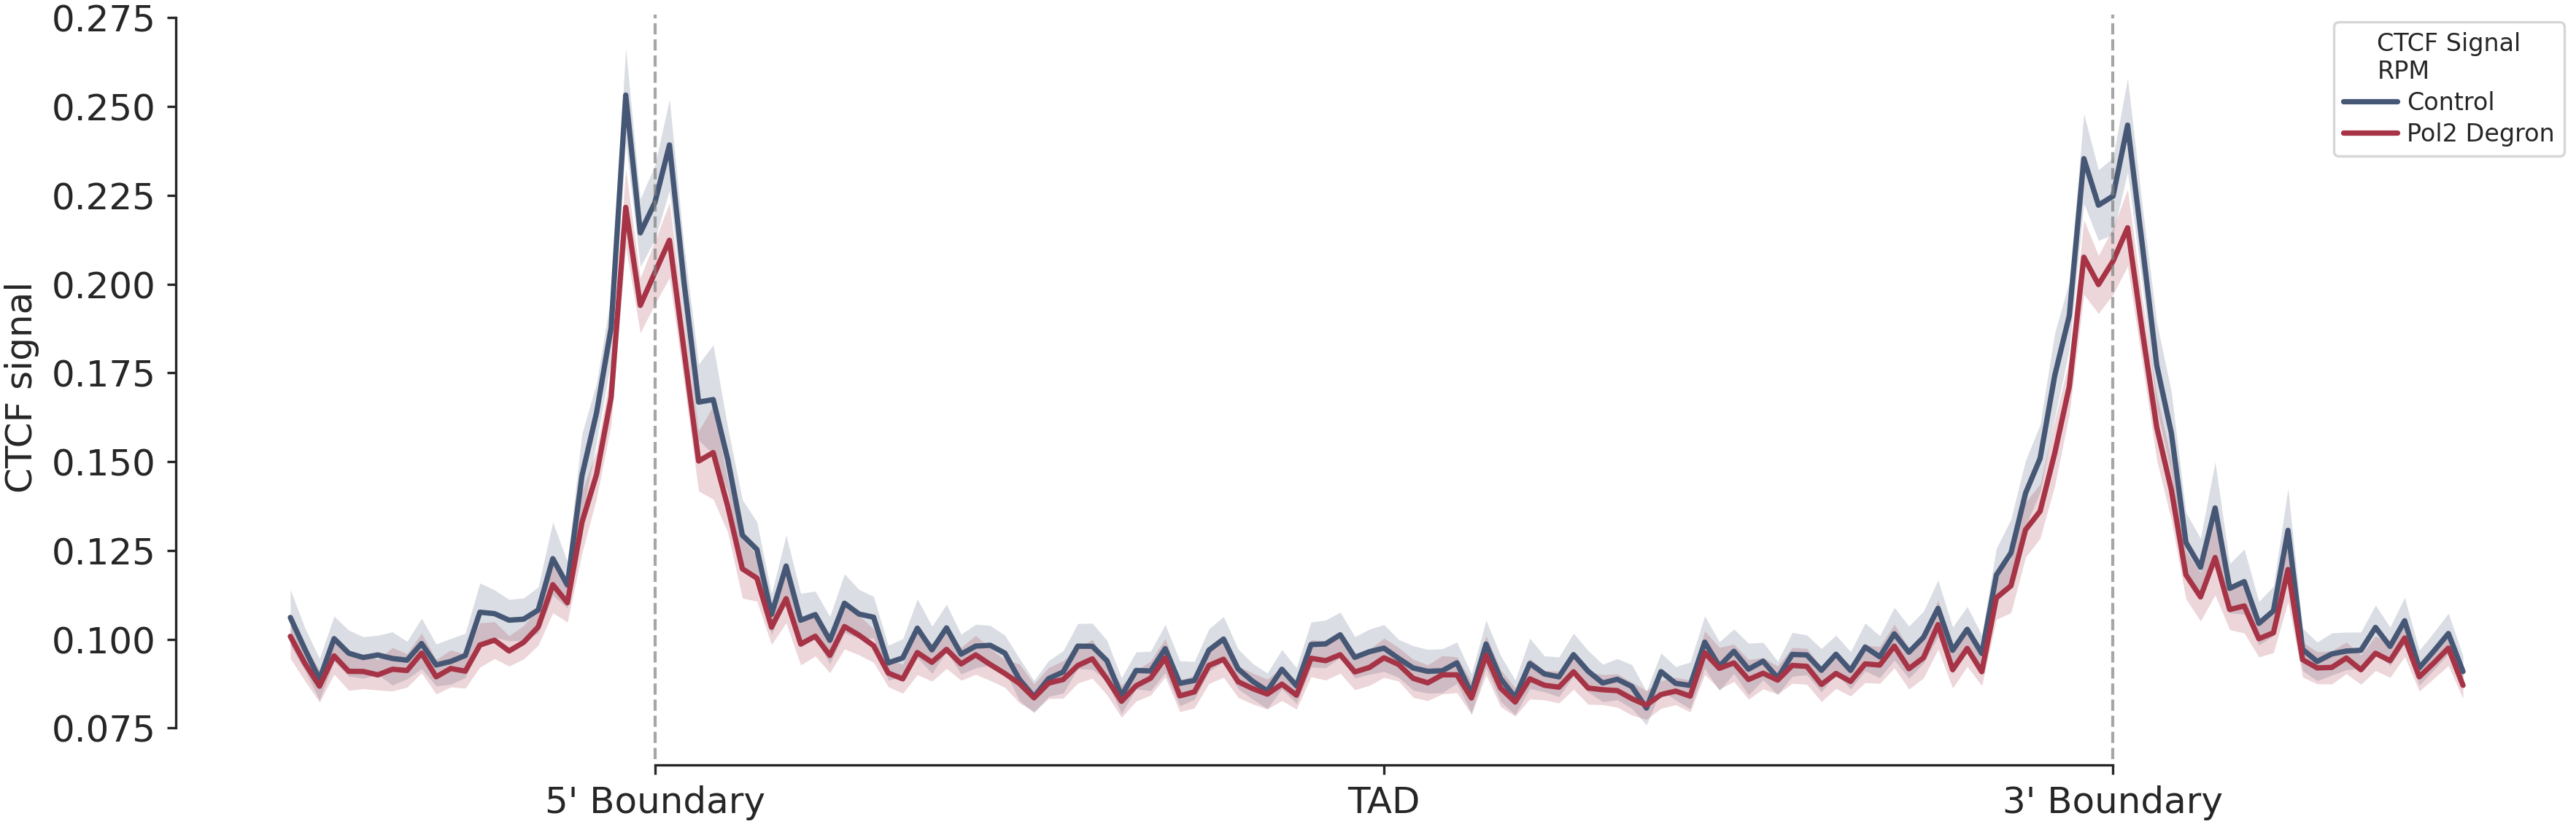

In [7]:
colors = list(reversed(plotting.COLORS))
fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharex='col')

common_params = {
    'plot_kwargs': {'linewidth': 1.75},
    'colors': plotting.COLORS[:2]
}

lineplot_stackup_dict(
    ctcf_stackup,
    ax=ax,
    labels={
        'control': 'Control',
        'degron': 'Pol2 Degron'
    },
    legend_title='CTCF Signal\nRPM',
    y_title='CTCF signal',
    structure_type='TAD',
    **common_params
)

# make all tick labels bigger
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plotting.despine(ax)

fig.tight_layout()

fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig5/fig5_degron_ctcf.png', dpi=300, bbox_inches='tight')
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig5/fig5_degron_ctcf.svg', dpi=300, bbox_inches='tight')